## Regression Modelling

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Load Dataset

In [23]:
# Load Independent Variables
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

#Load  independent features into a pandas dataframe
df = pd.DataFrame(housing.data, columns=housing.feature_names) 

In [24]:

# Load Dependent Variable
df['MedHouseVal'] = housing.target

df['MedHouseVal'].head()



0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [25]:
# Get Dataset Specifications using describe and info methods
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Q1. Fitting a Simple Linear Regression Model


In [26]:
# Fit the simplest possible model (1 predictor) first, as a baseline to compare all later, more complex models against.

# Set X and y for the simplest model (1 predictor)
x=df[['MedInc']] #used to declare the independent variable as x 

y=df[['MedHouseVal']] #used to declare the independent variable as y
# Initialize and fit the simplest model (1 predictor)
simple_model=LinearRegression()
simple_model.fit(x,y)

# Print the cofficient and intercept of the simplest model (1 predictor)

print(f"Intercept : {simple_model.intercept_[0]:.4f}")
print(f"Coeffcient : {simple_model.coef_[0][0]:.4f}")


Intercept : 0.4509
Coeffcient : 0.4179


for model 

## Q2. Making a Prediction
Using the model from Q51, predict the `MedHouseVal` for a housing block with a median income of 5.0 (i.e., $50,000). How does this compare to the actual average `MedHouseVal` of blocks with similar income in the dataset?


In [27]:
predicted_at_5 = simple_model.predict([[5.0]])[0][0]
print(f"Predicted value : {predicted_at_5}")

Predicted value : 2.540548227127493


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
similar_income = df[(df['MedInc'] >= 4.8) & (df['MedInc'] <= 5.2)]
actual_avg = similar_income['MedHouseVal'].mean()
print(f"Actual average MedHouseVal for MedInc in [4.8, 5.2]: {actual_avg:.4f} (${actual_avg*100000:,.0f})")
print(f"Number of blocks in that income range: {len(similar_income)}")
print(f"Difference (predicted - actual): {predicted_at_5 - actual_avg:.4f}")


Actual average MedHouseVal for MedInc in [4.8, 5.2]: 2.4937 ($249,368)
Number of blocks in that income range: 1123
Difference (predicted - actual): 0.0469


## Q3. Visualizing the Best Fit Line


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


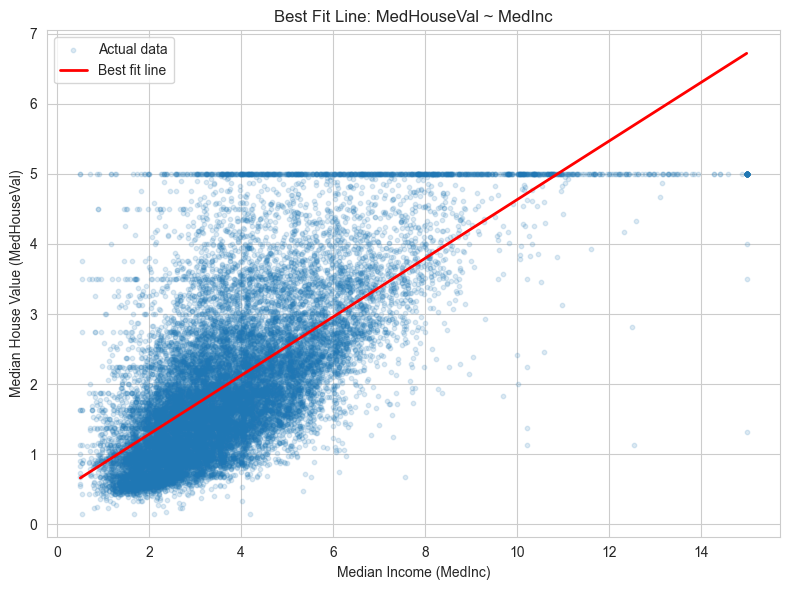

In [29]:
# Overlaying the fitted line on the scatter is the clearestvway to visually audit where the model fits well vs. poorly.

plt.figure(figsize=(8, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.15, s=10, label='Actual data')

x_range = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 200).reshape(-1, 1)
y_range_pred = simple_model.predict(x_range)
plt.plot(x_range, y_range_pred, color='red', linewidth=2, label='Best fit line')

plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Best Fit Line: MedHouseVal ~ MedInc')
plt.legend()
plt.tight_layout()
plt.show()


## Q4. Train-Test Split
Split the dataset into training and test sets (e.g., 80/20) before fitting the model. Refit your simple linear regression model on the training set only. Why is this train-test split necessary before evaluating a regression model?


In [30]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [35]:

from sklearn.model_selection import train_test_split

# Define Independent and Dependent Variables for Train-Test Split
X=df[['MedInc']]
y=df['MedHouseVal']

model_tt=LinearRegression()
# Create Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model_tt.fit(X_train,y_train)
# Initialize and fit the simplest model (1 predictor) on the training data
y_pred=model_tt.predict(X_train)

# Check the sizes of the training and testing datasets, as well as the model's intercept and coefficient
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

print(f"Intercept: {model_tt.intercept_:.4f}, Coefficient: {model_tt.coef_[0]:.4f}")


Train size: 16512, Test size: 4128
Intercept: 0.4446, Coefficient: 0.4193


#  Gradient Descent Algorithm


## Q5. Implementing Gradient Descent from Scratch
Implement a simple gradient descent algorithm from scratch (using NumPy only, no scikit-learn) to fit a single-predictor regression of `MedHouseVal` on `MedInc`. Track and plot the cost function value over iterations to confirm it decreases.

**Tip:** scale `MedInc` first using Standard Scaler — gradient descent converges much faster on scaled features.


Final beta0: 2.0686
Final beta1: 0.7940
Final cost (MSE): 0.7011


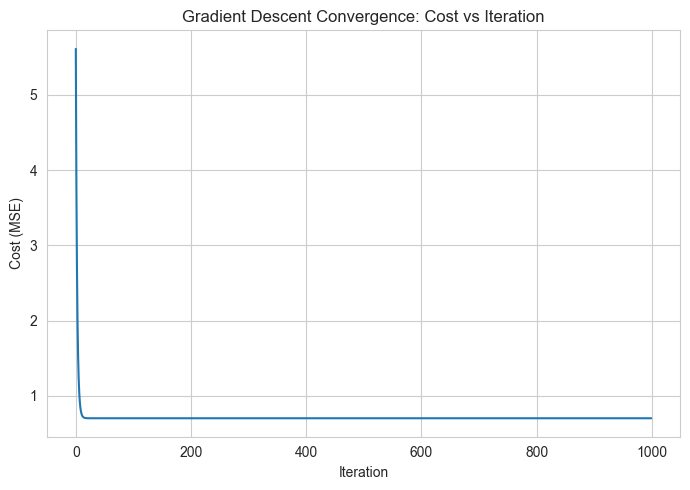

In [32]:

scaler_gd = StandardScaler()
X_scaled = scaler_gd.fit_transform(df[['MedInc']]).flatten()
y_gd = df['MedHouseVal'].values

beta0, beta1 = 0.0, 0.0
learning_rate = 0.1
n_iterations = 1000
n = len(X_scaled)
cost_history = []

for i in range(n_iterations):
    y_pred = beta0 + beta1 * X_scaled
    error = y_pred - y_gd

    # Partial derivatives of MSE = mean(error^2) w.r.t. beta0 and beta1
    d_beta0 = (2 / n) * np.sum(error)
    d_beta1 = (2 / n) * np.sum(error * X_scaled)

    beta0 -= learning_rate * d_beta0
    beta1 -= learning_rate * d_beta1

    cost = np.mean(error ** 2)
    cost_history.append(cost)

print(f"Final beta0: {beta0:.4f}")
print(f"Final beta1: {beta1:.4f}")
print(f"Final cost (MSE): {cost_history[-1]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(n_iterations), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence: Cost vs Iteration')
plt.tight_layout()
plt.show()


## Q6. Comparing Gradient Descent to scikit-learn
Compare the final β₀ and β₁ values obtained from your gradient descent implementation (Q57) to the values obtained from scikit-learn's `LinearRegression` (Q51, refit on the same scaled feature). Are they approximately equal? If not, what might explain the difference?


In [33]:
# Justification: fit scikit-learn's closed-form/optimized solver on the
# exact same scaled feature used in Q57, so the comparison is apples-to-apples.
X_scaled_2d = X_scaled.reshape(-1, 1)
sklearn_scaled_model = LinearRegression()
sklearn_scaled_model.fit(X_scaled_2d, y_gd)

print(f"scikit-learn intercept: {sklearn_scaled_model.intercept_:.4f}")
print(f"scikit-learn coefficient: {sklearn_scaled_model.coef_[0]:.4f}")
print()
print(f"Gradient descent intercept: {beta0:.4f}")
print(f"Gradient descent coefficient: {beta1:.4f}")
print()
print(f"Difference in intercept: {abs(sklearn_scaled_model.intercept_ - beta0):.6f}")
print(f"Difference in coefficient: {abs(sklearn_scaled_model.coef_[0] - beta1):.6f}")


scikit-learn intercept: 2.0686
scikit-learn coefficient: 0.7940

Gradient descent intercept: 2.0686
Gradient descent coefficient: 0.7940

Difference in intercept: 0.000000
Difference in coefficient: 0.000000


# Evaluate Model Performance (MAE, MSE, RMSE, R², Adjusted R²)


## Q7. Mean Absolute Error (MAE)
Using the model from Q54 (trained on the training set), generate predictions on the test set. Calculate the Mean Absolute Error (MAE). What does this value mean in terms of actual house value (remember `MedHouseVal` is in $100,000s)?


In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# predictions on the test set

y_pred_test=model_tt.predict(X_test)
#Calculate Mean Absolute Error (MAE) in $100,000 units and in actual dollars
mae=mean_absolute_error(y_test,y_pred_test)

print(f"MAE (in $100,000 units): {mae:.4f}")
print(f"MAE (in actual dollars): ${mae * 100000:,.0f}")


MAE (in $100,000 units): 0.6299
MAE (in actual dollars): $62,991


## Q8. MSE and RMSE
Calculate the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) for the same test set predictions. Why does RMSE penalize large errors more heavily than MAE?


In [38]:
# calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) in $100,000 units and in actual dollars

mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)


print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} (in $100,000 units) -> ${rmse * 100000:,.0f}")
print(f"For comparison, MAE was: {mae:.4f} (${mae * 100000:,.0f})")
print(f"RMSE - MAE: {rmse - mae:.4f}")


MSE: 0.7091
RMSE: 0.8421 (in $100,000 units) -> $84,209
For comparison, MAE was: 0.6299 ($62,991)
RMSE - MAE: 0.2122


## Q9. R² (Coefficient of Determination)
Calculate the R² (coefficient of determination) for your model. What does an R² of, say, 0.47 mean in terms of how much variance in `MedHouseVal` is explained by `MedInc`?


In [40]:
# Calculate R^2 on the test set to summarize overall explanatory power in a single, scale-free number, complementing the dollar-denominated MAE/RMSE metrics above.

r2 = r2_score(y_test, y_pred_test)
print(f"R^2 (single-predictor model, MedInc only): {r2:.4f}")


R^2 (single-predictor model, MedInc only): 0.4589


## Q10. Building a Multiple Linear Regression Model
Build a multiple linear regression model predicting `MedHouseVal` using all eight available predictors (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`). Report the fitted equation, confirm this matches the "multiple regression" definition from Q46, and calculate its R². Does adding more predictors always increase R², and why can that be misleading?


In [41]:
# Use ALL 8 predictors together (multiple regression) and
# reuse the same random_state so the test split
# making the R^2 comparison between the two models fair and direct.

# Set X and y for the multiple regression model (8 predictors)
X_multi = df.drop(columns=['MedHouseVal'])

y = df['MedHouseVal']

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()

multi_model.fit(X_multi_train, y_multi_train)

print(f"Intercept: {multi_model.intercept_:.4f}")
print("Coefficients:")
for name, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"  {name:12s}: {coef:.4f}")

y_multi_pred = multi_model.predict(X_multi_test)
r2_multi = r2_score(y_multi_test, y_multi_pred)
print(f"\nR^2 (multiple regression, 8 predictors): {r2_multi:.4f}")
print(f"R^2 (single predictor, MedInc only, from Q61): {r2:.4f}")
print(f"Improvement in R^2: {r2_multi - r2:.4f}")


Intercept: -37.0233
Coefficients:
  MedInc      : 0.4487
  HouseAge    : 0.0097
  AveRooms    : -0.1233
  AveBedrms   : 0.7831
  Population  : -0.0000
  AveOccup    : -0.0035
  Latitude    : -0.4198
  Longitude   : -0.4337

R^2 (multiple regression, 8 predictors): 0.5758
R^2 (single predictor, MedInc only, from Q61): 0.4589
Improvement in R^2: 0.1169


## Q11. Adjusted R²
Calculate the Adjusted R² for both the single-predictor model (Q61) and the multiple regression model (Q62). How does Adjusted R² correct for the issue identified in Q62?


In [43]:
# Justification: adjusted R^2 penalizes for the number of predictors, giving
# a fairer comparison between the 1-predictor and 8-predictor models than
# plain R^2 (Q62) can provide on its own.

def adjusted_r2(r2_value, n, p):
    return 1 - (1 - r2_value) * (n - 1) / (n - p - 1)

n_test = len(y_test)  # same test set size for both models (same random_state/split ratio)

adj_r2_simple = adjusted_r2(r2, n_test, p=1)
adj_r2_multi = adjusted_r2(r2_multi, n_test, p=8)

print(f"Simple model  (p=1): R^2 = {r2:.4f}, Adjusted R^2 = {adj_r2_simple:.4f}")
print(f"Multiple model (p=8): R^2 = {r2_multi:.4f}, Adjusted R^2 = {adj_r2_multi:.4f}")


Simple model  (p=1): R^2 = 0.4589, Adjusted R^2 = 0.4587
Multiple model (p=8): R^2 = 0.5758, Adjusted R^2 = 0.5750


# Section: Polynomial Regression


## Q12. Polynomial vs Linear Fit
Plot `MedHouseVal` against `MedInc` again, but this time overlay both a straight line fit and a polynomial fit (degree 2 or 3) using `PolynomialFeatures` + `LinearRegression`. Does the polynomial curve capture the relationship better than the straight line, particularly at higher income levels?


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


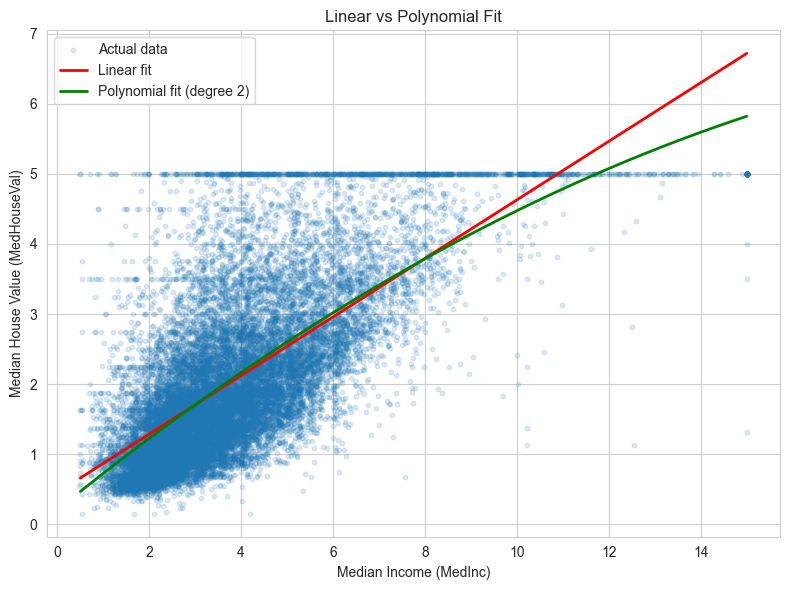

In [42]:
# Justification: overlay a straight-line fit and a degree-2/3 polynomial
# fit on the same scatter to visually judge whether curvature helps capture
# the MedInc/MedHouseVal relationship, especially at high incomes.
X_poly_base = df[['MedInc']]
y_poly_base = df['MedHouseVal']

linear_model_q64 = LinearRegression().fit(X_poly_base, y_poly_base)

poly_degree = 2
poly_transformer = PolynomialFeatures(degree=poly_degree)
X_poly_transformed = poly_transformer.fit_transform(X_poly_base)
poly_model = LinearRegression().fit(X_poly_transformed, y_poly_base)

x_smooth = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 300).reshape(-1, 1)
y_linear_smooth = linear_model_q64.predict(x_smooth)
y_poly_smooth = poly_model.predict(poly_transformer.transform(x_smooth))

plt.figure(figsize=(8, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.15, s=10, label='Actual data')
plt.plot(x_smooth, y_linear_smooth, color='red', linewidth=2, label='Linear fit')
plt.plot(x_smooth, y_poly_smooth, color='green', linewidth=2, label=f'Polynomial fit (degree {poly_degree})')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Linear vs Polynomial Fit')
plt.legend()
plt.tight_layout()
plt.show()


## Q13. Comparing R²: Linear vs Polynomial
Compare the R² of the linear model vs. the polynomial model from Q64. Is a higher R² for the polynomial model always a good sign? Discuss the risk of overfitting with higher polynomial degrees.


In [ ]:
# Justification: compare R^2 on a genuine held-out TEST set (not just
# training data) across increasing polynomial degrees, which is the only
# way to actually detect overfitting rather than just "better training fit."
X_poly_base = df[['MedInc']]
y_poly_base = df['MedHouseVal']
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_poly_base, y_poly_base, test_size=0.2, random_state=42
)

# Degree 1 (linear) baseline
lin_model = LinearRegression().fit(Xp_train, yp_train)
r2_lin_train = r2_score(yp_train, lin_model.predict(Xp_train))
r2_lin_test = r2_score(yp_test, lin_model.predict(Xp_test))

results = [("Linear (deg 1)", r2_lin_train, r2_lin_test)]

for degree in [2, 3, 5]:
    poly_t = PolynomialFeatures(degree=degree)
    Xp_train_t = poly_t.fit_transform(Xp_train)
    Xp_test_t = poly_t.transform(Xp_test)

    pm = LinearRegression().fit(Xp_train_t, yp_train)
    r2_train_d = r2_score(yp_train, pm.predict(Xp_train_t))
    r2_test_d = r2_score(yp_test, pm.predict(Xp_test_t))
    results.append((f"Polynomial (deg {degree})", r2_train_d, r2_test_d))

print(f"{'Model':<20}{'Train R2':>12}{'Test R2':>12}{'Gap (train-test)':>20}")
for name, tr, te in results:
    print(f"{name:<20}{tr:12.4f}{te:12.4f}{tr - te:20.4f}")


Model                   Train R2     Test R2    Gap (train-test)
Linear (deg 1)            0.4770      0.4589              0.0181
Polynomial (deg 2)        0.4816      0.4633              0.0183
Polynomial (deg 3)        0.4908      0.4671              0.0237
Polynomial (deg 5)        0.4910      0.4668              0.0242


## Q14. Standardized Coefficients — Feature Importance
Using the multiple linear regression model from Q62, identify which predictor has the largest standardized coefficient (hint: scale predictors first using Standard Scaler). What does this tell you about which feature most strongly drives `MedHouseVal`?

**Bonus:** does `Latitude`/`Longitude` show up as important — what real-world explanation might that have, given this is California housing data?


In [ ]:
# Justification: scale ALL predictors to the same units (mean 0, std 1)
# before comparing coefficient magnitudes -- raw coefficients aren't
# comparable across features measured in wildly different units/scales
# (e.g. Population in the thousands vs Latitude in the tens).
X_multi = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(X_multi)

scaled_model = LinearRegression()
scaled_model.fit(X_multi_scaled, y)

coef_df = pd.DataFrame({
    'feature': X_multi.columns,
    'standardized_coef': scaled_model.coef_
})
coef_df['abs_coef'] = coef_df['standardized_coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
print(coef_df[['feature', 'standardized_coef']])


      feature  standardized_coef
0    Latitude          -0.899886
1   Longitude          -0.870541
2      MedInc           0.829619
3   AveBedrms           0.305696
4    AveRooms          -0.265527
5    HouseAge           0.118752
6    AveOccup          -0.039326
7  Population          -0.004503


In [ ]:
str1=input("Enter the string of your choice")
str2=str1.split(" ")
ans = ''.join(str2).lower()
ok = ''.join(sorted(ans))
print(ok)

aadeehmoorruwyy


In [73]:
ele="python"
guess= '- '*len(ele)
mid=guess.split(" ")
print(guess)
for i in range(len(ele)):
    ch=input("Enter the guess")
    for j,c in enumerate(ele):
        if c==ch:
            mid[j]=ch
            guess=''.join(mid)
    print(guess)

- - - - - - 
p-----
py----
pyt---
pyth--
pytho-
python
